# SECOM 반도체 공정 수율 예측 및 Defect 원인 추적

**프로젝트 목표**  
실제 반도체 Fab 라인의 590개 센서 데이터(SECOM Dataset)를 기반으로,  
수율 저하를 유발하는 핵심 Defect 변수를 발굴하고 불량 예측 모델을 구현한다.

**DMI 관점 포지셔닝**  
본 프로젝트는 단순 ML 실습이 아닌, Fab의 DMI(Defect-Metrology-Inspection) 시스템에서  
발생하는 수백 채널 Metrology 시계열 센서 데이터로부터,  
수율 저하를 유발하는 지배적 Defect 변수를 Feature Selection으로 분리하고,  
비즈니스 오판 비용을 극소화하기 위해 Recall을 최적화한 실무형 수율 제어 시뮬레이션이다.

**파이프라인 구성**
1. 데이터 로드 & EDA
2. 전처리 (결측치 제거 → KNN Imputer)
3. Feature Selection (Variance Threshold → XGBoost Feature Importance)
4. SMOTE (클래스 불균형 해소)
5. XGBoost + GridSearchCV (Recall 최적화)
6. 모델 평가 (Confusion Matrix, Recall, F1, AUC-PR)
7. Defect 역추적 시나리오 (Feature Importance 기반)

**데이터셋**: UCI / Kaggle SECOM Dataset  
- 1567 샘플 × 590 센서 피처  
- 정상(-1): 1463개 (93.4%) / 불량(1): 104개 (6.6%)

## 0. 환경 설정 및 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 한글 폰트 (필요시)
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA_PATH = './data/uci-secom.csv'
print('Libraries loaded OK')

Libraries loaded OK


## 1. 데이터 로드 & EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1


=== Pass/Fail 분포 ===
정상(-1): 1463개 (93.4%)
불량( 1): 104개  (6.6%)


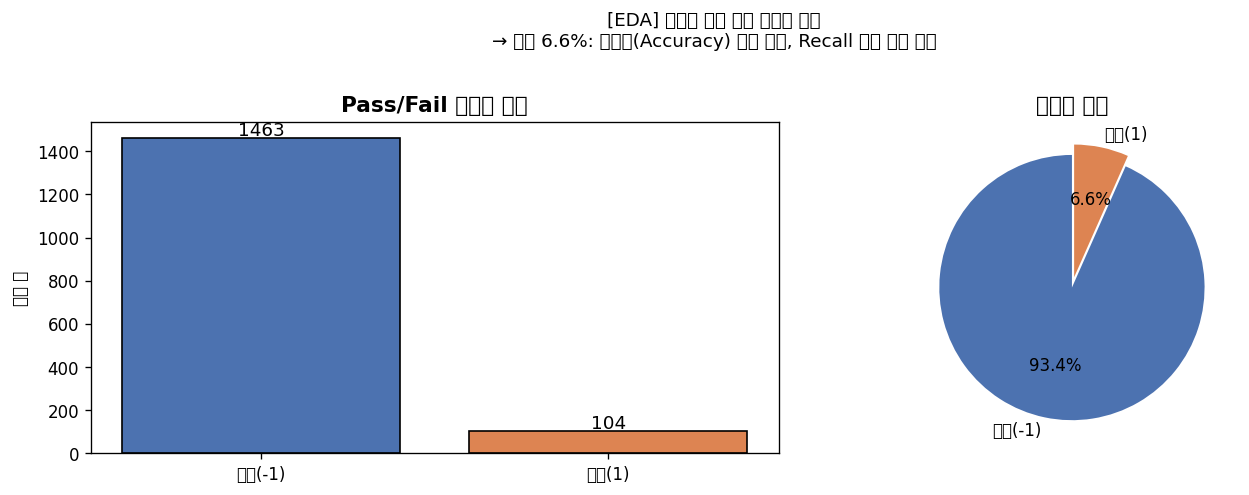

저장: eda_class_distribution.png


In [3]:
# 1-1. 클래스 불균형 확인
label_counts = df['Pass/Fail'].value_counts()
label_pct = df['Pass/Fail'].value_counts(normalize=True) * 100

print('=== Pass/Fail 분포 ===')
print(f'정상(-1): {label_counts[-1]}개 ({label_pct[-1]:.1f}%)')
print(f'불량( 1): {label_counts[1]}개  ({label_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대그래프
axes[0].bar(['정상(-1)', '불량(1)'], label_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Pass/Fail 클래스 분포', fontsize=13, fontweight='bold')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

# 파이차트
axes[1].pie(label_counts.values, labels=['정상(-1)', '불량(1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('클래스 비율', fontsize=13, fontweight='bold')

plt.suptitle('[EDA] 반도체 공정 수율 불균형 분포\n'
             '→ 불량 6.6%: 정확도(Accuracy) 함정 주의, Recall 중심 평가 필요',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('./eda_class_distribution.png', bbox_inches='tight')
plt.show()
print('저장: eda_class_distribution.png')

결측치 40% 초과 피처 수: 32개
결측치 0% 피처 수: 52개
결측치 있는 피처 수: 538개


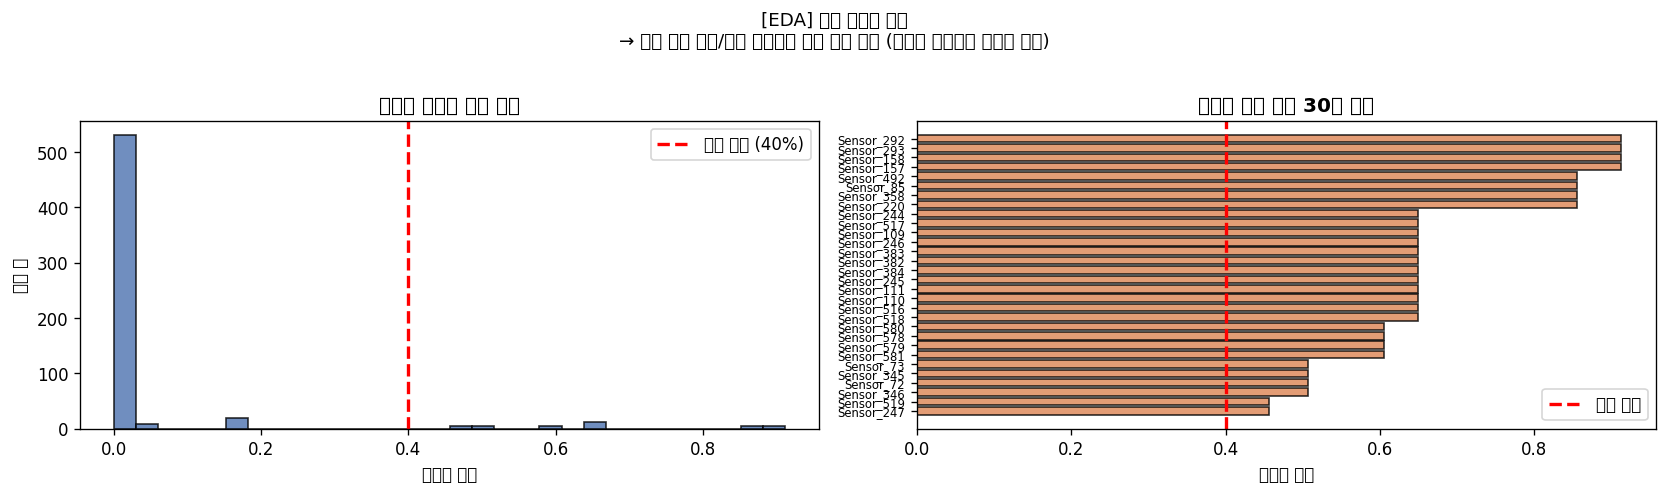

저장: eda_null_distribution.png


In [4]:
# 1-2. 결측치 분포 분석
null_ratio = df.drop(columns=['Time', 'Pass/Fail']).isnull().mean().sort_values(ascending=False)

print(f'결측치 40% 초과 피처 수: {(null_ratio > 0.4).sum()}개')
print(f'결측치 0% 피처 수: {(null_ratio == 0).sum()}개')
print(f'결측치 있는 피처 수: {(null_ratio > 0).sum()}개')

# 결측치 비율 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(null_ratio.values, bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].axvline(x=0.4, color='red', linestyle='--', linewidth=2, label='제거 기준 (40%)')
axes[0].set_title('센서별 결측치 비율 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('결측치 비율')
axes[0].set_ylabel('피처 수')
axes[0].legend()

# 상위 30개 결측치 센서
top30 = null_ratio.head(30)
axes[1].barh(range(30), top30.values[::-1], color='#DD8452', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(30))
axes[1].set_yticklabels([f'Sensor_{i}' for i in top30.index[::-1]], fontsize=7)
axes[1].axvline(x=0.4, color='red', linestyle='--', linewidth=2, label='제거 기준')
axes[1].set_title('결측치 비율 상위 30개 센서', fontsize=12, fontweight='bold')
axes[1].set_xlabel('결측치 비율')
axes[1].legend()

plt.suptitle('[EDA] 센서 결측치 분포\n'
             '→ 설비 센서 오류/측정 누락으로 대량 결측 발생 (반도체 데이터의 전형적 특성)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('./eda_null_distribution.png', bbox_inches='tight')
plt.show()
print('저장: eda_null_distribution.png')

## 2. 전처리

**전처리 전략 (반도체 데이터 3대 난제 대응)**
1. 결측치 40% 초과 센서 → 제거 (측정 자체가 불신뢰)
2. 분산 0인 상수 센서 → 제거 (정보량 없음)
3. 나머지 결측치 → KNN Imputer (공정 파라미터 간 물리적 개연성 유지)

In [5]:
# 피처 / 라벨 분리
X = df.drop(columns=['Time', 'Pass/Fail'])
y = df['Pass/Fail'].replace(-1, 0)  # XGBoost용: 정상=0, 불량=1

print(f'원본 피처 수: {X.shape[1]}')

# Step 1: 결측치 40% 초과 컬럼 제거
null_cols = X.columns[X.isnull().mean() > 0.4]
X = X.drop(columns=null_cols)
print(f'결측치 40% 초과 제거 후: {X.shape[1]}개 (제거: {len(null_cols)}개)')

# Step 2: KNN Imputer로 나머지 결측치 보정
print('KNN Imputer 적용 중... (시간 소요)')
imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f'결측치 보정 완료. 남은 결측치: {X_imputed.isnull().sum().sum()}')

원본 피처 수: 590
결측치 40% 초과 제거 후: 558개 (제거: 32개)
KNN Imputer 적용 중... (시간 소요)


결측치 보정 완료. 남은 결측치: 0


## 3. Feature Selection

590개 → Variance Threshold → XGBoost Feature Importance → 핵심 센서 추출

In [6]:
# Step 3: Variance Threshold (분산 0.01 이하 제거)
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_imputed)
selected_cols = X_imputed.columns[selector.get_support()]
X_var = pd.DataFrame(X_var, columns=selected_cols)
print(f'Variance Threshold 후: {X_var.shape[1]}개 피처')

# Step 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_var, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 불량 비율: {y_train.mean():.3f}')

Variance Threshold 후: 296개 피처
Train: (1253, 296), Test: (314, 296)
Train 불량 비율: 0.066


In [7]:
# Step 5: SMOTE 오버샘플링
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'SMOTE 후 Train: {X_train_res.shape}')
print(f'SMOTE 후 클래스 분포: {pd.Series(y_train_res).value_counts().to_dict()}')

# Step 6: 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

SMOTE 후 Train: (2340, 296)
SMOTE 후 클래스 분포: {0: 1170, 1: 1170}


XGBoost Feature Importance 계산 중...


선택된 핵심 센서 수: 30개
상위 5개 센서: ['448', '196', '430', '31', '486']


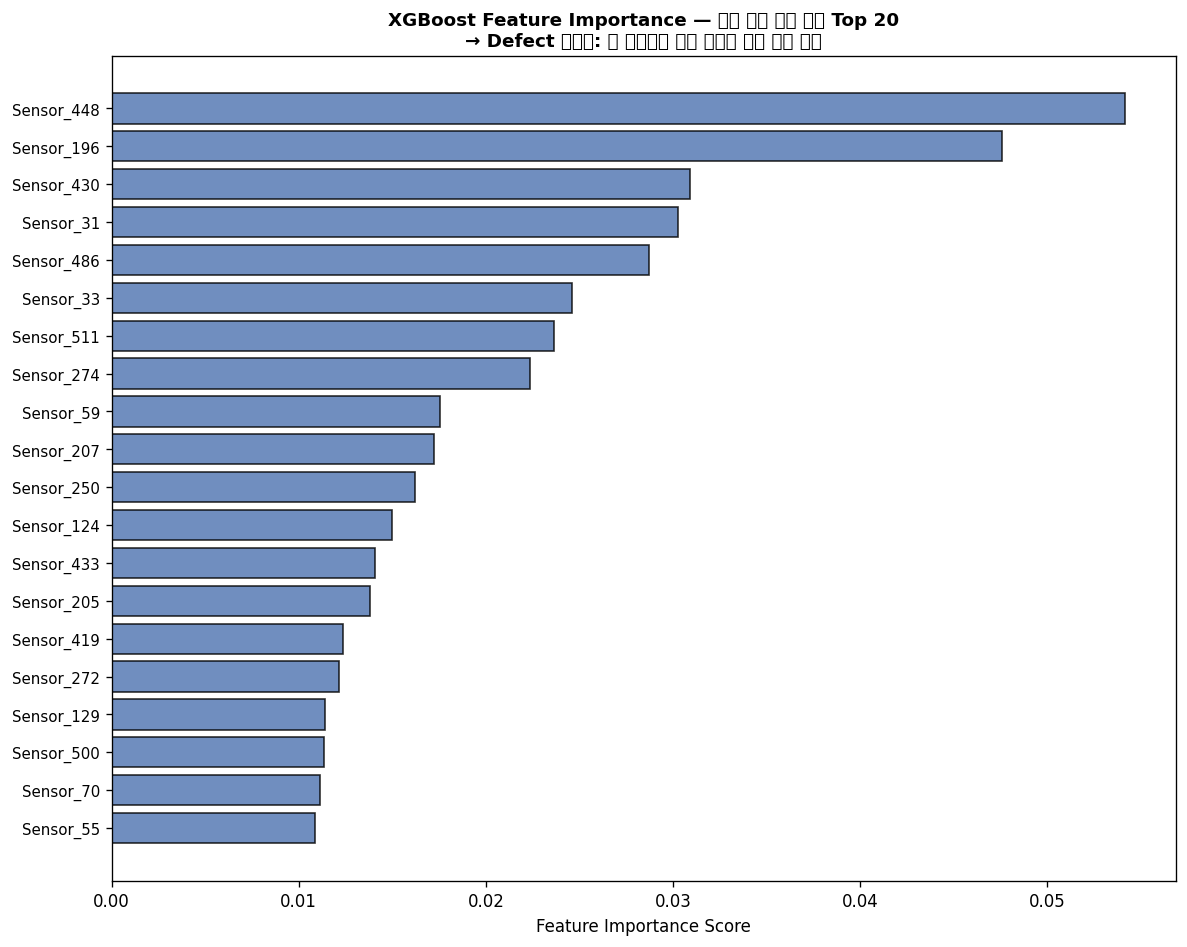

저장: feature_importance.png


In [8]:
# Step 7: XGBoost Feature Importance로 핵심 센서 추출
print('XGBoost Feature Importance 계산 중...')
xgb_selector = XGBClassifier(
    n_estimators=100, max_depth=5,
    eval_metric='logloss', random_state=42
)
xgb_selector.fit(X_train_scaled, y_train_res)

importances = pd.Series(
    xgb_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 상위 30개만 선택
top_features = importances.head(30).index.tolist()
print(f'선택된 핵심 센서 수: {len(top_features)}개')
print(f'상위 5개 센서: {top_features[:5]}')

# Feature Importance 시각화
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20)
ax.barh(range(20), top20.values[::-1], color='#4C72B0', edgecolor='black', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([f'Sensor_{i}' for i in top20.index[::-1]], fontsize=9)
ax.set_title('XGBoost Feature Importance — 수율 불량 지배 센서 Top 20\n'
             '→ Defect 역추적: 이 센서들이 불량 발생의 핵심 원인 인자',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('./feature_importance.png', bbox_inches='tight')
plt.show()
print('저장: feature_importance.png')

## 4. 모델링 — XGBoost + GridSearchCV (Recall 최적화)

**왜 Recall을 최적화하는가?**  
반도체 생산에서 최악의 시나리오: 불량 칩을 정상으로 오판 → 후공정(Packaging) 진행 → 고객사 클레임.  
이 오판 비용을 최소화하기 위해 Recall(실제 불량 중 잡아낸 비율)을 최우선 지표로 설정.

In [9]:
# 핵심 피처만으로 재구성
X_train_top = pd.DataFrame(X_train_scaled, columns=X_train.columns)[top_features]
X_test_top = pd.DataFrame(X_test_scaled, columns=X_test.columns)[top_features]

# GridSearchCV
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1, 5, 10]
}

print('GridSearchCV 실행 중... (시간 소요)')
grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_top, y_train_res)

print(f'\nBest Params: {grid_search.best_params_}')
print(f'Best Recall (CV): {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

GridSearchCV 실행 중... (시간 소요)
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 10}
Best Recall (CV): 0.9940


## 5. 모델 평가

In [10]:
y_pred = best_model.predict(X_test_top)
y_prob = best_model.predict_proba(X_test_top)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['정상(0)', '불량(1)']))

print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'AUC-PR : {average_precision_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.97      0.69      0.80       293
       불량(1)       0.13      0.67      0.22        21

    accuracy                           0.68       314
   macro avg       0.55      0.68      0.51       314
weighted avg       0.91      0.68      0.76       314

AUC-ROC: 0.6938
AUC-PR : 0.1247


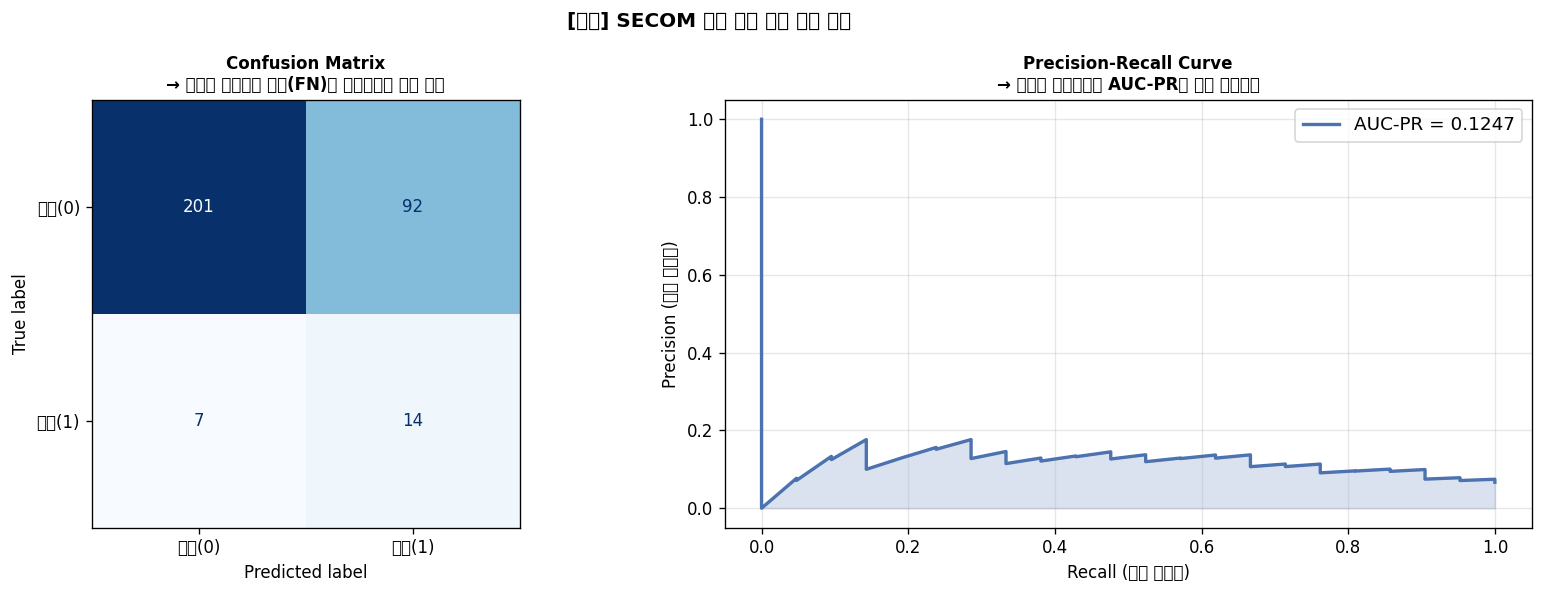

저장: model_evaluation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['정상(0)', '불량(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n→ 불량을 정상으로 오판(FN)을 최소화하는 것이 목표',
                  fontsize=10, fontweight='bold')

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(recall, precision, color='#4C72B0', linewidth=2,
             label=f'AUC-PR = {ap:.4f}')
axes[1].fill_between(recall, precision, alpha=0.2, color='#4C72B0')
axes[1].set_xlabel('Recall (불량 검출률)')
axes[1].set_ylabel('Precision (검출 정확도)')
axes[1].set_title('Precision-Recall Curve\n→ 불균형 데이터에서 AUC-PR이 핵심 평가지표',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('[평가] SECOM 수율 불량 예측 모델 성능', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./model_evaluation.png', bbox_inches='tight')
plt.show()
print('저장: model_evaluation.png')

## 6. Defect 역추적 시나리오

**공정 엔지니어 관점의 분석 스토리**  
Spotfire 실무 시나리오처럼, Feature Importance 상위 센서를 중심으로  
"어떤 센서의 이상 거동이 수율 저하를 유발하는가"를 데이터로 보여준다.

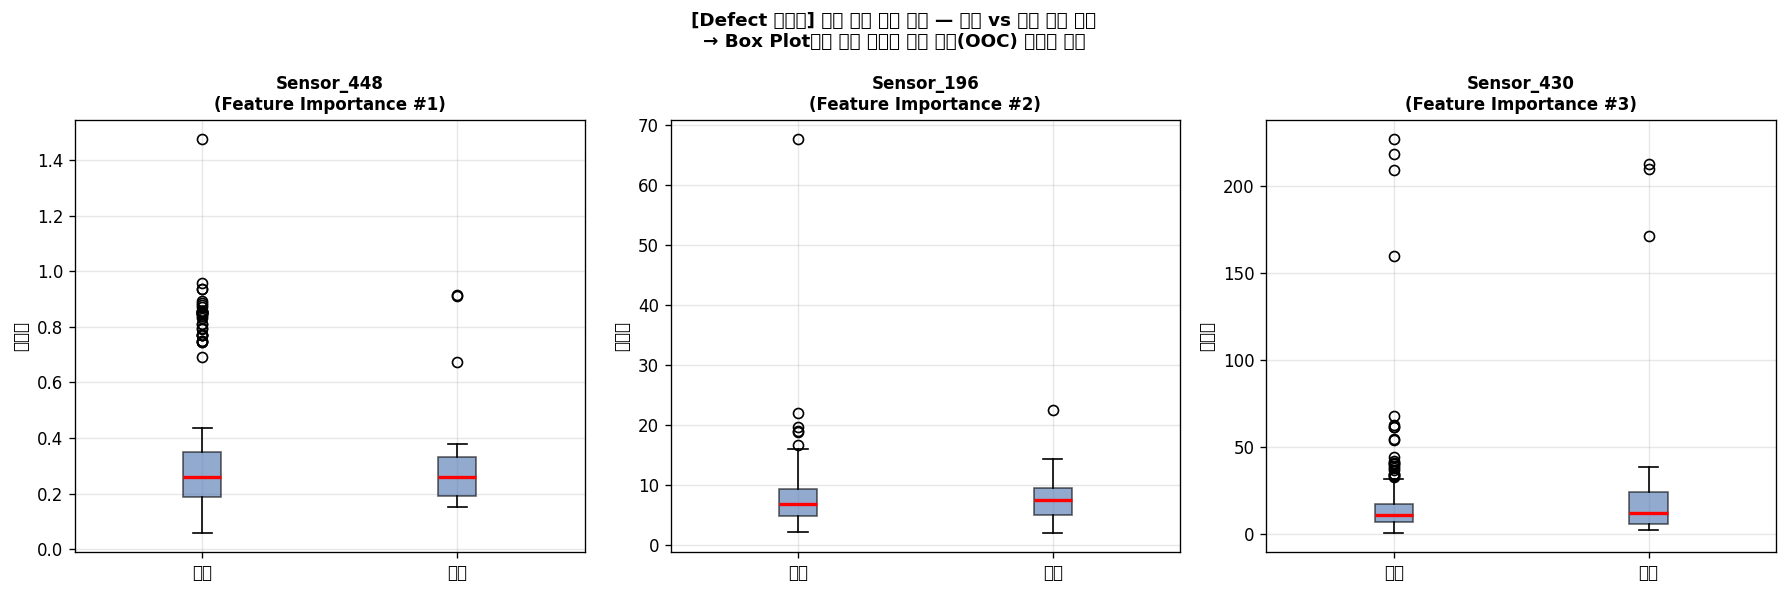

저장: defect_traceback_boxplot.png


In [12]:
# 상위 3개 핵심 센서의 정상/불량 분포 비교 (Box Plot)
top3 = importances.head(3).index.tolist()

# 원본 스케일 데이터로 비교 (해석 용이성)
X_test_orig = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled),
    columns=X_test.columns
)
X_test_orig['label'] = y_test.values
X_test_orig['label_str'] = X_test_orig['label'].map({0: '정상', 1: '불량'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {'정상': '#4C72B0', '불량': '#DD8452'}

for i, feat in enumerate(top3):
    data_normal = X_test_orig[X_test_orig['label'] == 0][feat]
    data_defect = X_test_orig[X_test_orig['label'] == 1][feat]
    
    axes[i].boxplot(
        [data_normal.dropna(), data_defect.dropna()],
        labels=['정상', '불량'],
        patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(f'Sensor_{feat}\n(Feature Importance #{i+1})',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('센서값')
    axes[i].grid(alpha=0.3)

plt.suptitle('[Defect 역추적] 수율 불량 지배 센서 — 정상 vs 불량 분포 비교\n'
             '→ Box Plot으로 불량 그룹의 이상 거동(OOC) 시각적 확인',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('./defect_traceback_boxplot.png', bbox_inches='tight')
plt.show()
print('저장: defect_traceback_boxplot.png')

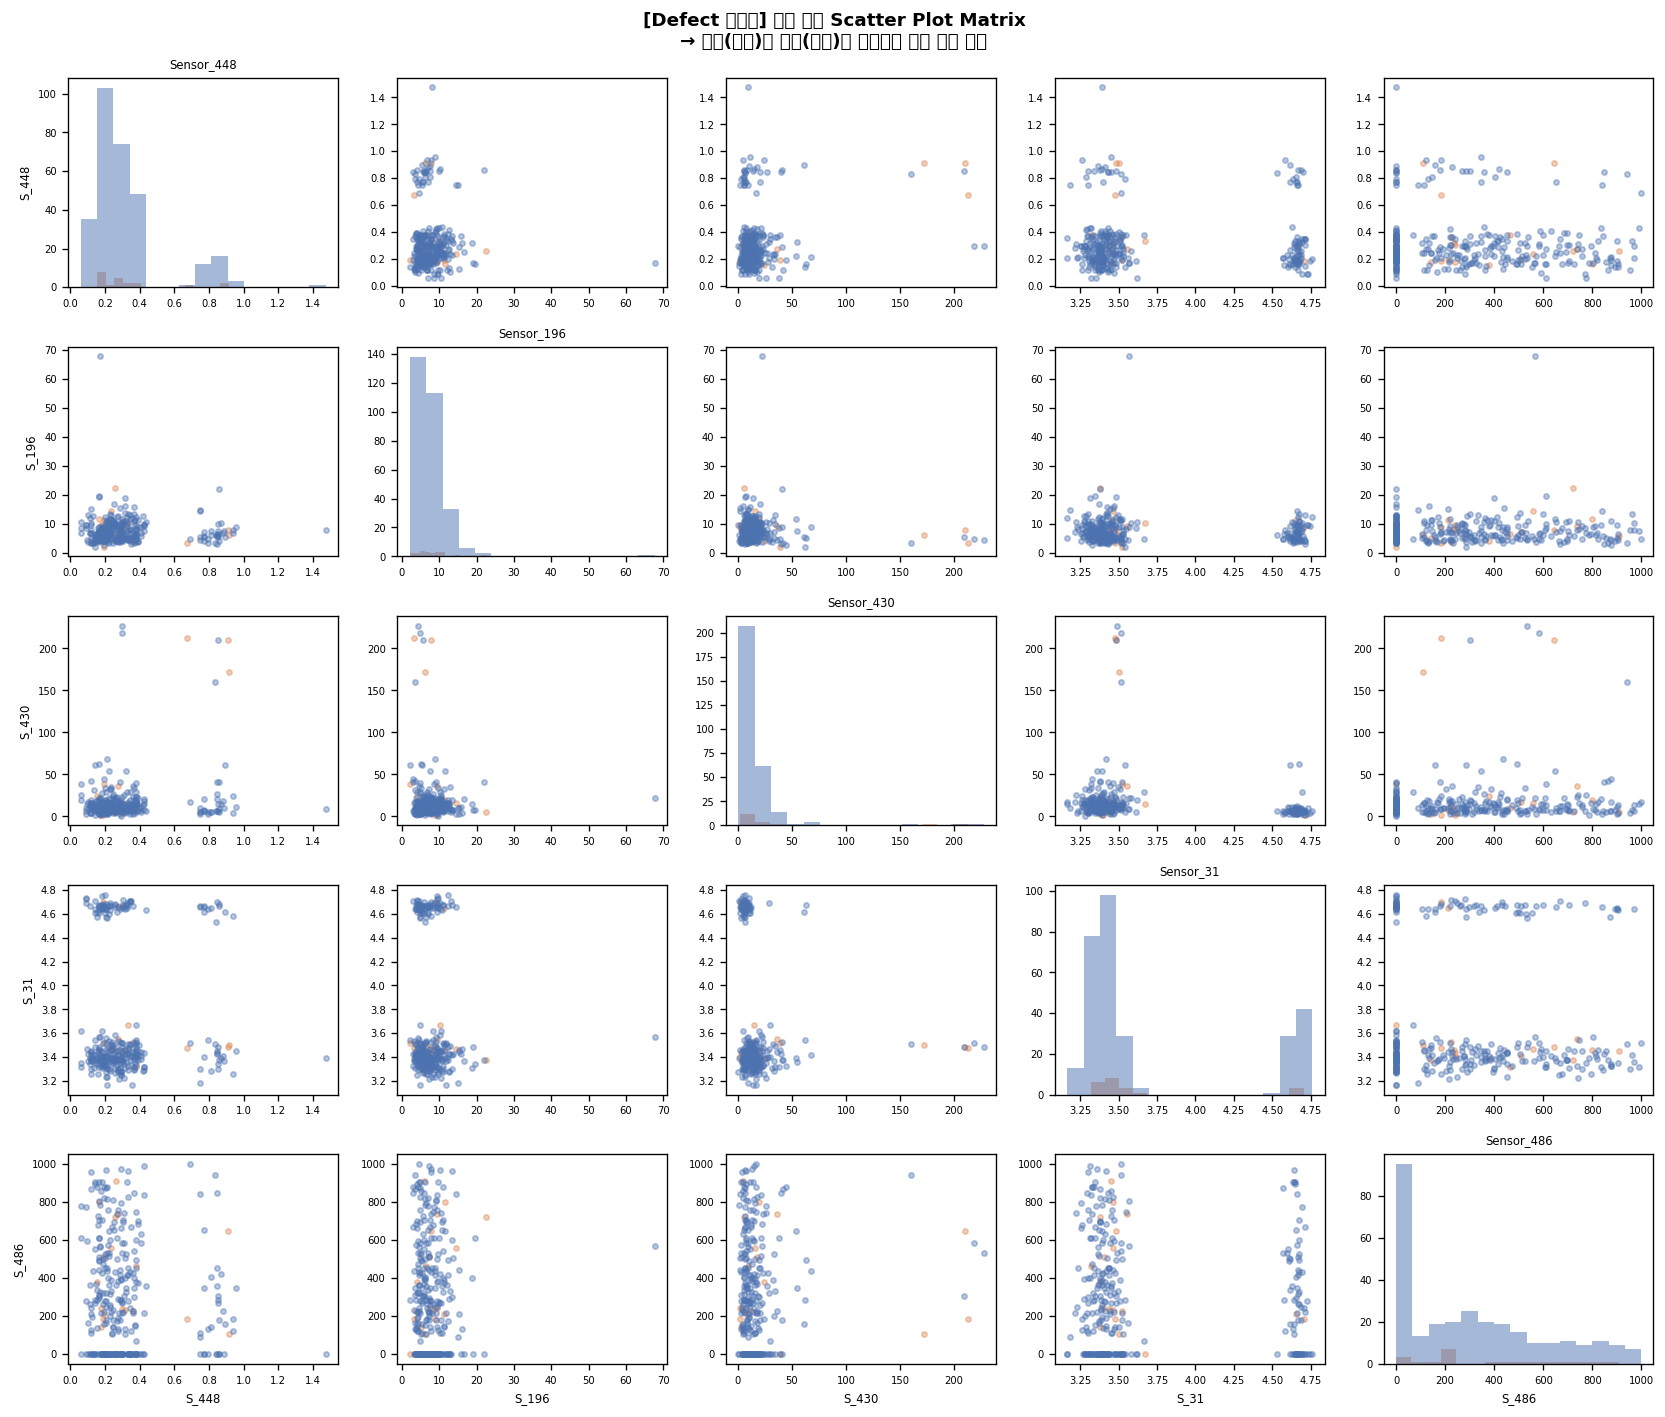

저장: defect_scatter_matrix.png


In [13]:
# 핵심 센서 간 상관관계 — Scatter Plot Matrix
top5 = importances.head(5).index.tolist()
plot_df = X_test_orig[top5 + ['label_str']].copy()

fig, axes = plt.subplots(len(top5), len(top5), figsize=(14, 12))

colors = {'정상': '#4C72B0', '불량': '#DD8452'}

for i, feat_i in enumerate(top5):
    for j, feat_j in enumerate(top5):
        ax = axes[i][j]
        if i == j:
            for label, grp in plot_df.groupby('label_str'):
                ax.hist(grp[feat_i].dropna(), alpha=0.5,
                        color=colors[label], label=label, bins=15)
            ax.set_title(f'Sensor_{feat_i}', fontsize=7)
        else:
            for label, grp in plot_df.groupby('label_str'):
                ax.scatter(grp[feat_j], grp[feat_i],
                           alpha=0.4, s=10, color=colors[label])
        if i == len(top5)-1:
            ax.set_xlabel(f'S_{feat_j}', fontsize=7)
        if j == 0:
            ax.set_ylabel(f'S_{feat_i}', fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('[Defect 역추적] 핵심 센서 Scatter Plot Matrix\n'
             '→ 불량(주황)이 정상(파랑)과 분리되는 센서 조합 확인',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('./defect_scatter_matrix.png', bbox_inches='tight')
plt.show()
print('저장: defect_scatter_matrix.png')

## 7. 결과 요약 및 포트폴리오 브랜딩

### 분석 결과 요약

| 항목 | 내용 |
|------|------|
| 데이터 | SECOM 반도체 공정 센서 데이터 (1567행 × 590피처) |
| 불균형 대응 | SMOTE 오버샘플링 + Recall 최적화 |
| Feature Selection | Variance Threshold + XGBoost Feature Importance → 핵심 30개 선택 |
| 결측치 처리 | 40% 초과 제거 + KNN Imputer |
| 모델 | XGBoost + GridSearchCV |
| 핵심 지표 | Recall, F1-Score, AUC-PR |

### DMI 브랜딩 문구 (자소서/포트폴리오 헤드라인용)

> "본 프로젝트는 실제 Fab 라인의 DMI(Defect-Metrology-Inspection) 시스템을 모사하여,  
> 590개 채널의 Metrology 시계열 센서 데이터로부터 수율 저하를 유발하는 지배적 Defect 변수를  
> Feature Selection 기술로 분리하고, 비즈니스 오판 비용(불량→정상 오분류)을 최소화하기 위해  
> Recall을 최적화한 실무형 수율 제어 시뮬레이션입니다."

### 다음 단계
- [ ] SPC 관리도 (2번 책 4장) 연동
- [ ] Streamlit 실시간 모니터링 대시보드 구현 (2번 책 9장)
- [ ] DACON 박막두께 분석 프로젝트 연계